Homework 3
Isabel Garcia
ig2303

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1

(a)

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
import statsmodels.formula.api as smf

In [4]:
temperature = pd.read_csv("shared/data/temperature.csv")
temperature.head()

,Unnamed: 0,longitude,latitude,1,2,3,4,5,6,7,8,9,10,11,12
0,79669,138.75,-4.75,28.5,28.7,28.5,30.2,29.9,28.8,27.3,28.5,28.4,28.4,29.2,29.0
1,79091,136.75,-14.25,29.4,29.8,29.0,29.7,28.2,26.0,23.9,26.0,26.4,28.3,29.8,30.2
2,22723,-57.75,-19.75,28.8,29.0,28.2,25.5,23.6,22.6,24.7,25.4,26.6,27.7,28.1,28.1
3,40355,22.75,-18.25,25.7,25.6,25.6,24.9,21.3,18.0,17.7,21.0,25.1,28.7,27.7,26.1
4,17837,-71.75,-40.25,10.9,10.0,7.9,5.3,2.8,1.9,-0.2,-0.2,1.4,3.6,6.5,8.1


In [5]:
temperature.describe()

,Unnamed: 0,longitude,latitude,1,2,3,4,5,6,7,8,9,10,11,12
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.00000,2000.000000
mean,43306.043500,19.574250,13.372000,6.824850,8.642000,10.501250,12.540100,14.754800,16.392600,17.252250,17.264350,16.046450,14.0230,10.59775,8.362350
std,24243.581463,84.766522,36.880953,23.541216,21.850059,18.638445,15.432218,11.246473,9.238882,8.604856,9.010215,10.515672,14.1402,18.76903,21.649551
min,8.000000,-179.750000,-55.250000,-55.600000,-49.100000,-41.600000,-41.100000,-22.800000,-15.200000,-14.900000,-17.300000,-23.400000,-35.6000,-42.40000,-52.300000
25%,21964.250000,-60.750000,-18.875000,-12.400000,-11.200000,-4.700000,3.300000,8.300000,10.500000,11.400000,11.100000,8.900000,4.9000,-3.82500,-8.625000
50%,40671.000000,23.500000,0.000000,19.750000,20.750000,19.350000,17.800000,16.550000,16.900000,17.800000,18.500000,17.800000,18.8000,19.45000,19.600000
75%,67015.500000,101.250000,48.750000,25.400000,25.900000,25.700000,24.600000,23.800000,23.700000,24.200000,24.500000,24.700000,25.6000,25.40000,25.200000
max,85736.000000,178.750000,82.750000,34.300000,35.700000,32.200000,33.900000,34.900000,36.500000,36.700000,37.600000,35.000000,32.1000,33.10000,35.000000


In [6]:
data2 = temperature[["1","latitude"]]
data2.corr()

,1,latitude
1,1.000000,-0.880824
latitude,-0.880824,1.000000


In [7]:
temperature_renamed = temperature.rename(columns={"1": "january"})
temperature_renamed.head()

,Unnamed: 0,longitude,latitude,january,2,3,4,5,6,7,8,9,10,11,12
0,79669,138.75,-4.75,28.5,28.7,28.5,30.2,29.9,28.8,27.3,28.5,28.4,28.4,29.2,29.0
1,79091,136.75,-14.25,29.4,29.8,29.0,29.7,28.2,26.0,23.9,26.0,26.4,28.3,29.8,30.2
2,22723,-57.75,-19.75,28.8,29.0,28.2,25.5,23.6,22.6,24.7,25.4,26.6,27.7,28.1,28.1
3,40355,22.75,-18.25,25.7,25.6,25.6,24.9,21.3,18.0,17.7,21.0,25.1,28.7,27.7,26.1
4,17837,-71.75,-40.25,10.9,10.0,7.9,5.3,2.8,1.9,-0.2,-0.2,1.4,3.6,6.5,8.1


Text(0.5, 1.0, "Relationship Between Latitude and Temperature's in January")

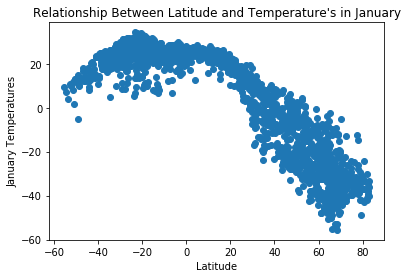

In [8]:
plt.scatter(temperature_renamed.latitude, temperature_renamed.january)
plt.xlabel("Latitude")
plt.ylabel("January Temperatures")
plt.title("Relationship Between Latitude and Temperature's in January")

In [9]:
temperature_renamed = temperature.rename(columns={"7": "july"})
temperature_renamed.head()

,Unnamed: 0,longitude,latitude,1,2,3,4,5,6,july,8,9,10,11,12
0,79669,138.75,-4.75,28.5,28.7,28.5,30.2,29.9,28.8,27.3,28.5,28.4,28.4,29.2,29.0
1,79091,136.75,-14.25,29.4,29.8,29.0,29.7,28.2,26.0,23.9,26.0,26.4,28.3,29.8,30.2
2,22723,-57.75,-19.75,28.8,29.0,28.2,25.5,23.6,22.6,24.7,25.4,26.6,27.7,28.1,28.1
3,40355,22.75,-18.25,25.7,25.6,25.6,24.9,21.3,18.0,17.7,21.0,25.1,28.7,27.7,26.1
4,17837,-71.75,-40.25,10.9,10.0,7.9,5.3,2.8,1.9,-0.2,-0.2,1.4,3.6,6.5,8.1


Text(0.5, 1.0, "Relationship Between Latitude and Temperature's in July")

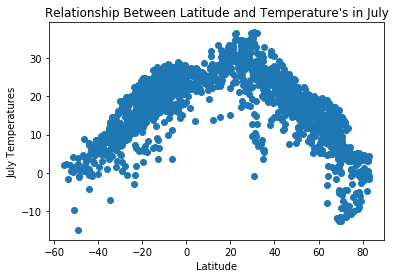

In [10]:
plt.scatter(temperature_renamed.latitude, temperature_renamed.july)
plt.xlabel("Latitude")
plt.ylabel("July Temperatures")
plt.title("Relationship Between Latitude and Temperature's in July")

In [43]:
data2 = temperature_renamed[["latitude","july"]]
data2.corr()

,latitude,july
latitude,1.000000,-0.090811
july,-0.090811,1.000000


(b) Yes, there is. Latitudes influence temperature. The closer you are to the equator(latitude = 0), the hotter the climate. Whereas, the farther you are, the colder -- like the North Pole has a latitude of 90. Latitude is one of the factors that influences temperature. The independent variable(latitude) should be on the x axis. The dependent variable(temperature), the one affected by the independent, should be on the y-axis. By plotting the scatter plot this way, we can see how temperatures during January/July vary across latitudes. In the scatter plots, you can see that there is a downwards curve when latitude is zero(closer to the equator and higher in temperature).  

(c) If you are asking if the correlation changes depending on if X is the month or latitude, then no. No matter how you plot correlation between January and Latitude, the number will stay the same. But, if you are asking if correlation changes depending on if X is January or July, then yes it does. In January, it is shown that latitude and temperature have a strong negative correlation (-0.8808). However, in July, it is shown that latitude and temperature have a weak negative correlation(-0.0908). 

(d) The pattern shown in both the July and January scatter plots is that, generally, the farther you are from the equator(latitude = 0) the colder a place(geographically speaking) gets. Given the correlations calculated, there is a negative correlation between latitude and temperature, meaning they have an inverse relationship. It is important to note that temperature in January has a much stronger correlation with latitude than temperature in July. January temperatures and latitude have a strong negative correlation of -0.8808. Whereas, July temperatures and latitude have a weak correlation of -0.0908. Both scatter plots show a downward facing curve. However, the July plot shows a more defined bell curve. Whereas, January's plot shows a more linear scatter plot. Because January's plot is more linear, the correlation coefficient is larger/stronger. The correlation coefficient does not measure non-linear relationships. This explains why July's correlation coefficient is so much weaker, even though the plot shows a clearer pattern. There are many different reasons why latitude and temperature have a negative correlation. One reason is because the Sun is able to hit the Earth's surface more directly at the equator. Thus, concentrating energy in a smaller area. Whereas, at the poles, the Sun directs its light at an angle. A reason why correlation between latitude and temp. changes seasonally is because the Earth's tilt changes as we move around the Sun. For example, in July in the Northern Hemisphere, the Sun is able to hit the Earth more directly and temperatures rise. But in January in the Northern Hemisphere, the northern part of the Earth is tilted away from the Sun and therefore sunlight reaches that part of the Earth at angle and can not direct as much energy to the Earth's surface so temperatures drop in the North. July and January may differ in correlations with latitude because of a number of things like geographical influences(altitude, ocean winds, etc.). 

Text(0.5, 1.0, 'Relationship Between Latitude and Longitude')

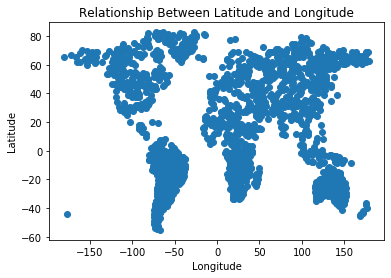

In [11]:
plt.scatter(temperature_renamed.longitude, temperature_renamed.latitude)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Relationship Between Latitude and Longitude")

In [23]:
print("The minimum longitude: ", np.min(temperature["longitude"]))
print("The maximum longitude: ", np.max(temperature["longitude"]))
print("This is the minimum latitude: ", np.min(temperature["latitude"]))
print("This is the maximum latitude: ", np.max(temperature["latitude"]))

The minimum longitude:  -179.75
The maximum longitude:  178.75
This is the minimum latitude:  -55.25
This is the maximum latitude:  82.75


The distribution of weather does not appear to be a random sample of the Earth's surface. This is because all of the data points represent land. This data frame does not include temperatures not on land. We have a biased sample of data. The range of latitude seems to be missing data from the poles. Particularly in the Southern Hemisphere; the lowest the data goes is -55. Because the weather stations are unevenly distributed across latitudes, the correlation coefficient could be affected by this. This, along with missing the oceans, shows that we may not have data that accurately reflects the relationship between latitude and temperature.

(f)

,july,latitude
july,1.000000,0.853957
latitude,0.853957,1.000000


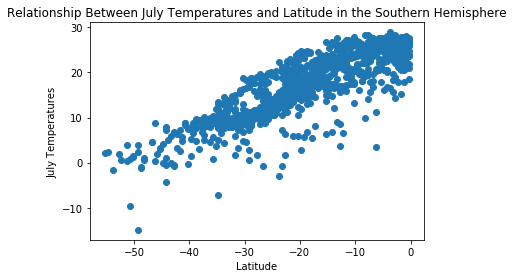

In [29]:
southern_hemisphere = temperature_renamed[temperature_renamed['latitude'] < 0]
plt.scatter(southern_hemisphere.latitude, southern_hemisphere.july)
plt.xlabel("Latitude")
plt.ylabel("July Temperatures")
plt.title("Relationship Between July Temperatures and Latitude in the Southern Hemisphere")
data = southern_hemisphere[["july","latitude"]]
data.corr()

The correlation between latitudes in the Southern Hemisphere and temperatures in July is 0.8540.

,1,latitude
1,1.000000,-0.904428
latitude,-0.904428,1.000000


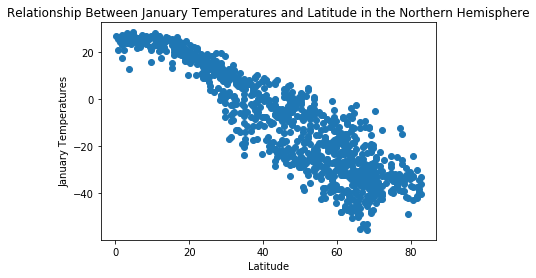

In [34]:
northern_hemisphere = temperature_renamed[temperature_renamed['latitude'] > 0]
plt.scatter(northern_hemisphere['latitude'], northern_hemisphere['1'])
plt.xlabel("Latitude")
plt.ylabel("January Temperatures")
plt.title("Relationship Between January Temperatures and Latitude in the Northern Hemisphere")
data = northern_hemisphere[["1","latitude"]]
data.corr()

The correlation between latitudes in the Northern Hemisphere and temperatures in January is -0.9044.

(g) Temperatures during January in the Northern Hemisphere have a stronger correlational relationship than temperatures during July in the Southern Hemisphere. It is important to note that the correlation coefficient in Jan/North plot is negative, but in the July/South plot the coefficient is positive. This does not mean that one has an inverse relationship and the other has a direct relationship. It was just calculated as such because in the Southern Hemisphere, the latitudes are in the negatives. If you look at this data with absolute value in mind with latitude, the pattern we see here is that temperatures decrease the greater the number in latitude. In other words, the farther the latitude is from the number zero(equator), the colder it gets. The closer the latitude is to zero, the warmer in temperature it gets. Another thing to note, which may explain why July/South has a weaker correlation coefficient may be because there is less data. The data only ranges from -60 to 0, whereas in the Jan/North plot the data ranges from 80 to 0. 

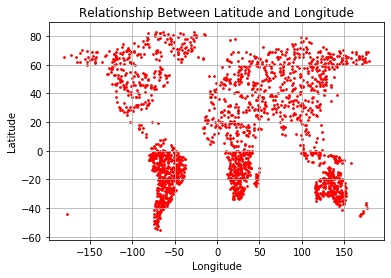

In [72]:
plt.scatter(temperature_renamed.longitude, temperature_renamed.latitude, s = 3, c = 'red')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Relationship Between Latitude and Longitude")
plt.grid(True)

I made the data points smaller, changed the color to one I prefer, and added grid lines. Now, we are able to see how unevenly distributed the data is. If not for this improvement, I would not have known that our data has is a high concentration of weather stations from 3 regions of the world. 

Problem 2

(a)

In [43]:
momiq = pd.read_csv("shared/data/momiq.csv")
momiq.head()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,1,121.117529,4,27
1,98,1,89.361882,4,25
2,85,1,115.443165,4,27
3,83,1,99.449639,3,25
4,115,1,92.745710,4,27


The slope of the regression line = p * (σy / σx)

(b) The mother's IQ will be the explanatory variable, X. And, the kid's test score will the response variable Y. I chose it this way because we are trying to see that if the Mother's intelligence level impacts their child's intelligence level. It would not make sense if it were the other way around: the child's intelligence level impacts the mother's intelligence level. The correlation between the two is 0.4483. Thus, a mother's IQ level has a weak positive correlation with their children's test score.

,mom_iq,kid_score
mom_iq,1.000000,0.448276
kid_score,0.448276,1.000000


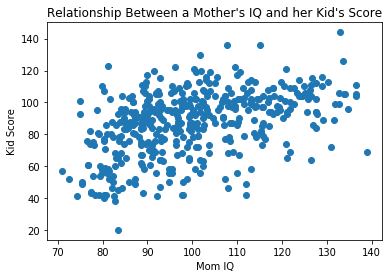

In [50]:
plt.scatter(momiq.mom_iq, momiq.kid_score)
plt.xlabel("Mom IQ")
plt.ylabel("Kid Score")
plt.title("Relationship Between a Mother's IQ and her Kid's Score")
data = momiq[["mom_iq","kid_score"]]
data.corr()

(c)

In [56]:
def standardize(col):
    mean = col.mean()     #find the mean of the column
    standardized = (col - mean)/ col.std()   #standardize
    return standardized     #get the output

(d)

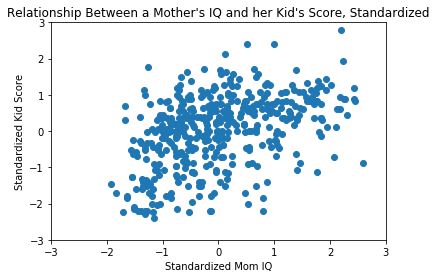

In [57]:
mom_iq2 = standardize(momiq["mom_iq"])
kid_score2 = standardize(momiq["kid_score"])
plt.xlabel("Standardized Mom IQ")
plt.ylabel("Standardized Kid Score")
plt.title("Relationship Between a Mother's IQ and her Kid's Score, Standardized")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.scatter(mom_iq2, kid_score2)

(f)

In [58]:
model = smf.ols("kid_score2 ~ mom_iq2", data = momiq).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             kid_score2   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     108.6
Date:                Tue, 05 Nov 2024   Prob (F-statistic):           7.66e-23
Time:                        10:38:38   Log-Likelihood:                -566.64
No. Observations:                 434   AIC:                             1137.
Df Residuals:                     432   BIC:                             1145.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.695e-16      0.043  -6.27e-15      1.000      -0.084       0.084
mom_iq2        0.4483      0.043     10.423      0.000       0.364       0.533
==============================================================================
Omnibus:                        7.545   Durbin-Watson:                   1.645
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.735
Skew:                          -0.324   Prob(JB):                       0.0209
Kurtosis:                       2.919   Cond. No.                         1.00
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The slope of the regression for this model is 0.4483. It is the same as the correlation coefficient. The number did not change before and after standardizing the data. Mothers' IQ and Kids' Scores have a weak, positive correlation. 

(f)

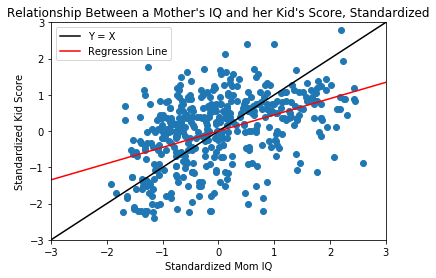

In [59]:
plt.xlabel("Standardized Mom IQ")
plt.ylabel("Standardized Kid Score")
plt.title("Relationship Between a Mother's IQ and her Kid's Score, Standardized")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.scatter(mom_iq2, kid_score2)

x1, y1 = [-3, 3], [-3, 3]
plt.plot(x1, y1, c = "black", label = "Y = X")

x2, y2 = [-3, 3], [-3*0.4483, 3*0.4483]
plt.plot(x2, y2, c = "red", label = "Regression Line")
plt.legend()

(g) The regression line seems to be the better fit of the data. It is hard to tell. Since the regression line is literally calculated to minimize residuals, I am going to assume that the regression line is the line of best fit out of these two options. The Y = X line increases as too much of an incline. 

Problem 3

(a) 

In [61]:
bread = pd.read_csv("shared/data/bread_votes.csv")
bread.head()

,demvotes,incumbent_party,repvotes,year,total_votes,incumbent_party_share,avg_recent_growth,dem_candidate,rep_candidate,winner,incumbent_victory
0,24179347,democrat,21991292,1948,46170639,0.523695,2.945063,Harry S. Truman,Thomas E. Dewey,Harry S. Truman,True
1,27375090,democrat,34075529,1952,61450619,0.445481,3.491052,Adlai Stevenson,Dwight D. Eisenhower,Dwight D. Eisenhower,False
2,26028028,republican,35579180,1956,61607208,0.577517,2.818698,Adlai Stevenson,Dwight D. Eisenhower,Dwight D. Eisenhower,True
3,34220984,republican,34108157,1960,68329141,0.499174,0.126799,John F. Kennedy,Richard Nixon,John F. Kennedy,False
4,43129040,democrat,27175754,1964,70304794,0.613458,4.391619,Lyndon B. Johnson,Barry Goldwater,Lyndon B. Johnson,True


In [67]:
print("The mean of average recent growth: ", round(np.mean(bread["avg_recent_growth"]), 2))
print("The standard deviation of average recent growth: ", round(np.std(bread["avg_recent_growth"]), 2))
print("The number of observations: ", bread.shape[0])

The mean of average recent growth:  2.5
The standard deviation of average recent growth:  1.36
The number of observations:  19


(b)

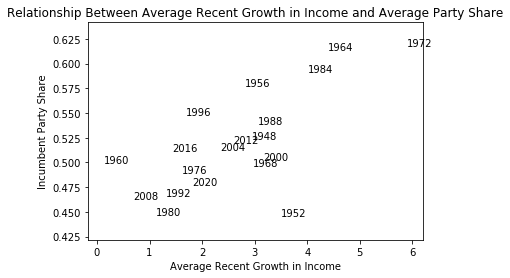

In [71]:
# create scatter plot
plt.xlabel("Average Recent Growth in Income")  #label x and y axis and title
plt.ylabel("Incumbent Party Share")
plt.title("Relationship Between Average Recent Growth in Income and Average Party Share")
plt.scatter(bread.avg_recent_growth, bread.incumbent_party_share, c = "white")   #get rid of the points, make the color white
                                                                                # set scatter plot, x and y

for i, row in bread.iterrows():      #iterrows is a pandas function that goes through every row over the data frame, in this case "bread", i = index
    plt.text(row["avg_recent_growth"], row["incumbent_party_share"],  str(row["year"]))  #setting the x and y values, then the string where the text(year) goes

plt.show()

(c)

In [73]:
data = bread[["avg_recent_growth","incumbent_party_share"]]
data.corr()

,avg_recent_growth,incumbent_party_share
avg_recent_growth,1.000000,0.697242
incumbent_party_share,0.697242,1.000000


In [76]:
print("The correlation between Average Recent Growth and Incumbent Party Share is", round(0.697242,3))

The correlation between Average Recent Growth and Incumbent Party Share is 0.697


The correlation coefficient tells us that Average Recent Income Growth and Incumbent Party Share have a linear, positive, direct, relatively strong correlation. This means that if average recent personal income growth increases, incumbent party share will most likely also increase. From this number, we can determine that R squared is 0.485. Which tells us that around 48.5% of incumbent party share can be explained by average recent personal income growth. This makes sense because the economy has a large input on who people vote for. If people are personally prospering, then they may want things to stay the way that they are. If it isn't broken, don't fix it. Thus, after a term with significantly high personal income growth, the incumbent party tends to see an increase in vote share. 

(d)

In [77]:
model = smf.ols("incumbent_party_share ~ avg_recent_growth", data = bread).fit()
model.summary()

/opt/conda/envs/dsua-111/lib/python3.7/site-packages/scipy/stats/stats.py:1535: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     incumbent_party_share   R-squared:                       0.486
Model:                               OLS   Adj. R-squared:                  0.456
Method:                    Least Squares   F-statistic:                     16.08
Date:                   Tue, 05 Nov 2024   Prob (F-statistic):           0.000907
Time:                           11:58:21   Log-Likelihood:                 35.970
No. Observations:                     19   AIC:                            -67.94
Df Residuals:                         17   BIC:                            -66.05
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4526      0.019     24.456      0.000       0.414       0.492
avg_recent_growth     0.0261      0.007      4.010      0.001       0.012       0.040
==============================================================================
Omnibus:                        3.434   Durbin-Watson:                   2.486
Prob(Omnibus):                  0.180   Jarque-Bera (JB):                1.621
Skew:                          -0.646   Prob(JB):                        0.445
Kurtosis:                       3.616   Cond. No.                         6.54
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The slope means that for every unit that average personal income growth increases, the incumbent party share of votes increases by 0.0261 units. The intercept means that when average recent personal income growth is at zero, the incumbent party share is 0.4526. 

(e)

In [114]:
y = (0.0261)*(2.47) + 0.4526
print("In 2024, the incumbent party's popular vote share is predicted to be", y*100, "%.")

In 2024, the incumbent party's popular vote share is predicted to be 51.706700000000005 %.


(f)

In [126]:
x = bread["avg_recent_growth"]
y = bread["incumbent_party_share"]
xnew = 2.47
xbar = bread["avg_recent_growth"].mean()     #finding the mean of x
n = len(bread)                               #number of observations
residuals = model.resid    
s = np.sqrt(np.sum(residuals**2) / (n - 2))  # finding the root mean square
ssd = np.sum((x - xbar)**2)                  # finding the sum of square deviations of x
SE = s * (np.sqrt(1 + (1/n) + ((xnew - xbar)**2 / ssd)))   # findi
ybarnew = 0.51707

In [127]:
print(SE)

0.03952570770428917


In [128]:
round(ybarnew - 2*SE, 2)

0.44

In [129]:
round(ybarnew + 2*SE, 2)

0.6

Confidence Interval: [.44, .60]